In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Display all the columns of the dataframe
# pd.pandas.set_option('display.max_columns',None)

In [69]:
df = pd.read_csv("dataset\steam_top_games_2026.csv")
df.head(5)


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\HP\AppData\Local\Temp\ipykernel_6864\1903245458.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("dataset\steam_top_games_2026.csv")


,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,...,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image
0,794260,Outward Definitive Edition,"May 17, 2022",False,4.79,False,88,Nine Dots Studio,"Prime Matter, Deep Silver",RPG,...,"1,000,000 .. 2,000,000",1332,824,465,469,0,1,72,No remarkable journey is achieved without grea...,https://shared.akamai.steamstatic.com/store_it...
1,253920,Gorky 17,"Sep 27, 2013",False,9.99,False,0,Metropolis Software,TopWare Interactive,"RPG, Strategy",...,"200,000 .. 500,000",301,0,328,61,17,2,0,November 2008. NATO intelligence services repo...,https://shared.akamai.steamstatic.com/store_it...
2,613010,Secret in Story,"Jun 19, 2017",False,0.89,False,10,Naivus Luo,Naivus Luo,"Adventure, Indie",...,"2,000,000 .. 5,000,000",251,0,243,0,0,0,32,"Accompanied by beautiful piano music, you begi...",https://shared.akamai.steamstatic.com/store_it...
3,892420,懒人修仙传,"Nov 14, 2018",False,3.99,False,0,托更的修罗,托更的修罗,"Casual, Indie, RPG, Simulation",...,"200,000 .. 500,000",5786,0,9223,41,0,0,0,这是一款很&quot;休闲&quot;的文字挂机游戏，游戏小而系统完善，玩法丰富，极其耗电，...,https://shared.akamai.steamstatic.com/store_it...
4,914010,Train Station Renovation,"Oct 1, 2020",False,18.99,False,0,Live Motion Games,"Live Motion Games, Frozen Way, PlayWay S.A., F...","Casual, Indie, Simulation",...,"200,000 .. 500,000",448,0,201,16,0,1,73,"Welcome to an old, ruined train station. A pla...",https://shared.akamai.steamstatic.com/store_it...


## Handling Missing Values

In [70]:
# cek nilai kosong
df.isnull().sum()

app_id                    0
name                      0
release_date              7
coming_soon               0
price_usd                 0
is_free                   0
discount_pct              0
developer                 8
publisher                12
genres                    8
categories                9
tags                      6
platforms_win             0
platforms_mac             0
platforms_linux           0
metacritic_score        955
recommendations           0
positive_reviews          0
negative_reviews          0
estimated_owners          5
avg_playtime_forever      0
avg_playtime_2weeks       0
median_playtime           0
peak_ccu                  0
required_age              0
dlc_count                 0
achievements              0
short_description         2
header_image              1
dtype: int64

In [71]:
## Hapus baris atau titik data untuk menangani nilai yang hilang
# menghitung baris sebelum dihapus
df.shape

(1495, 29)

In [72]:
# menghitung baris setelah dihapus
df.dropna().shape

(525, 29)

In [73]:
## Menghapus perkolom
df.dropna(axis=1)

,app_id,name,coming_soon,price_usd,is_free,discount_pct,platforms_win,platforms_mac,platforms_linux,recommendations,positive_reviews,negative_reviews,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements
0,794260,Outward Definitive Edition,False,4.79,False,88,True,False,False,23986,20738,7717,1332,824,465,469,0,1,72
1,253920,Gorky 17,False,9.99,False,0,True,True,True,909,1616,411,301,0,328,61,17,2,0
2,613010,Secret in Story,False,0.89,False,10,True,True,False,0,79,35,251,0,243,0,0,0,32
3,892420,懒人修仙传,False,3.99,False,0,True,False,False,1169,769,509,5786,0,9223,41,0,0,0
4,914010,Train Station Renovation,False,18.99,False,0,True,False,False,1948,2154,466,448,0,201,16,0,1,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1490,1590910,Forgive Me Father,False,19.99,False,0,True,False,False,3350,4083,742,204,0,106,61,0,1,20
1491,1693970,PARTY RUSH!!,False,9.99,False,0,True,False,False,0,12,6,0,0,0,0,0,1,15
1492,1225330,NBA 2K21,False,0.00,False,0,True,False,False,28213,16233,22823,6563,0,4090,148,0,0,50
1493,764030,Realm Revolutions,False,0.00,True,0,True,False,False,0,273,95,20080,0,4114,57,0,0,0



## Imputasi Nilai yang Hilang

<Axes: xlabel='metacritic_score', ylabel='Count'>

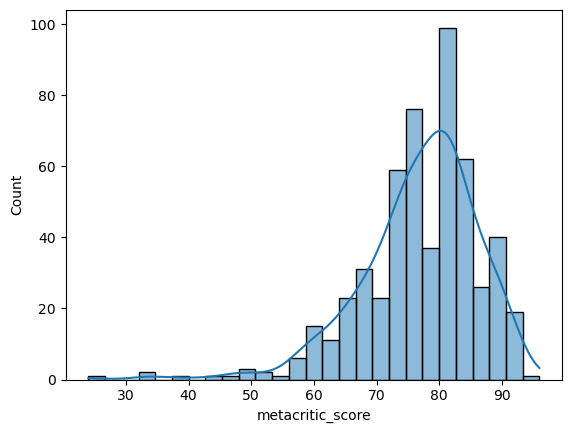

In [74]:
## Handle kolom metacritic_score  
sns.histplot(df['metacritic_score'],kde=True)


In [75]:
# mencari dan mengisi nilai median untuk kolom metacritic_score
df['metacritic_score_median']=df['metacritic_score'].fillna(df['metacritic_score'].median())
df['metacritic_score_median']

0       78.0
1       78.0
2       78.0
3       78.0
4       68.0
        ... 
1490    74.0
1491    78.0
1492    78.0
1493    78.0
1494    78.0
Name: metacritic_score_median, Length: 1495, dtype: float64

In [76]:
df[['metacritic_score','metacritic_score_median']]

,metacritic_score,metacritic_score_median
0,NaN,78.0
1,NaN,78.0
2,NaN,78.0
3,NaN,78.0
4,68.0,68.0
...,...,...
1490,74.0,74.0
1491,NaN,78.0
1492,NaN,78.0
1493,NaN,78.0


In [77]:
## Handle kolom release_date
#melihat jumlah data kosong
df[df['release_date'].isnull()]

,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,...,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image,metacritic_score_median
122,63380,Sniper Elite V2,NaN,False,0.00,False,0,Rebellion,Rebellion,Action,...,375,0,194,34,0,4,47,In the dark days of the end of World War Two a...,https://shared.akamai.steamstatic.com/store_it...,66.0
615,223850,3DMark,NaN,False,34.99,False,0,UL Solutions,UL Solutions,Utilities,...,937,454,246,699,0,21,29,"3DMark is for gamers, overclockers and system ...",https://shared.akamai.steamstatic.com/store_it...,78.0
652,214560,Mark of the Ninja,NaN,False,0.00,False,0,Klei Entertainment,Microsoft Studios,"Action, Adventure, Indie",...,362,0,201,2,17,0,38,"In Mark of the Ninja, you'll know what it is t...",https://shared.akamai.steamstatic.com/store_it...,91.0
719,224540,Ace of Spades: Battle Builder,NaN,False,0.00,False,0,Jagex Limited,Jagex Limited,"Action, Indie",...,563,0,264,0,0,0,77,Say hello to the creative shooter. Ace of Spad...,https://shared.akamai.steamstatic.com/store_it...,49.0
786,577800,NBA 2K18,NaN,False,0.00,False,0,Visual Concepts,2K,"Simulation, Sports",...,7360,0,4694,58,0,0,50,The highest rated* annual sports title returns...,https://shared.akamai.steamstatic.com/store_it...,87.0
842,44340,Operation Flashpoint: Red River,NaN,False,0.00,False,0,Codemasters Action Studio,Codemasters,"Action, Strategy",...,62,0,49,1,17,0,0,Stand together with the US Marines in Operatio...,https://shared.akamai.steamstatic.com/store_it...,67.0
1344,202170,Sleeping Dogs,NaN,False,0.00,False,0,United Front Games,Square Enix,"Action, Adventure",...,985,0,560,18,17,25,59,"As Wei Shen, an undercover cop trying to take ...",https://shared.akamai.steamstatic.com/store_it...,80.0


In [78]:
# mencari nilai uniq
df['release_date'].unique()

array(['May 17, 2022', 'Sep 27, 2013', 'Jun 19, 2017', ...,
       'Nov 14, 2014', 'Apr 7, 2022', 'Jan 5, 2018'],
      shape=(1187,), dtype=object)

In [79]:
# mencari dan mengisi nilai modus untuk kolom release_date
df['release_date_mode'] = df[df['release_date'].notna()]['release_date'].mode()[0]

In [80]:
#  melihat nilai null dan mode
df[df[['release_date_mode', 'release_date']].isnull().any(axis=1)].head(5)


,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,...,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image,metacritic_score_median,release_date_mode
122,63380,Sniper Elite V2,NaN,False,0.00,False,0,Rebellion,Rebellion,Action,...,0,194,34,0,4,47,In the dark days of the end of World War Two a...,https://shared.akamai.steamstatic.com/store_it...,66.0,"Apr 25, 2017"
615,223850,3DMark,NaN,False,34.99,False,0,UL Solutions,UL Solutions,Utilities,...,454,246,699,0,21,29,"3DMark is for gamers, overclockers and system ...",https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017"
652,214560,Mark of the Ninja,NaN,False,0.00,False,0,Klei Entertainment,Microsoft Studios,"Action, Adventure, Indie",...,0,201,2,17,0,38,"In Mark of the Ninja, you'll know what it is t...",https://shared.akamai.steamstatic.com/store_it...,91.0,"Apr 25, 2017"
719,224540,Ace of Spades: Battle Builder,NaN,False,0.00,False,0,Jagex Limited,Jagex Limited,"Action, Indie",...,0,264,0,0,0,77,Say hello to the creative shooter. Ace of Spad...,https://shared.akamai.steamstatic.com/store_it...,49.0,"Apr 25, 2017"
786,577800,NBA 2K18,NaN,False,0.00,False,0,Visual Concepts,2K,"Simulation, Sports",...,0,4694,58,0,0,50,The highest rated* annual sports title returns...,https://shared.akamai.steamstatic.com/store_it...,87.0,"Apr 25, 2017"


In [81]:
#cek  apakah nilai masin null
df['release_date_mode'].isnull().sum()

np.int64(0)

In [82]:
df['release_date'].isnull().sum()

np.int64(7)

In [83]:
## mengandle kolom publisher
#melihat jumlah data kosong
df[df['publisher'].isnull()].head(5)


,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,...,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image,metacritic_score_median,release_date_mode
87,945490,Little Square Things,"Sep 28, 2019",False,0.00,True,0,G.Reed,NaN,"Indie, Strategy",...,0,0,0,0,2,28,Forget the box. Think outside the entire wareh...,https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017"
109,783140,Removed,"Apr 13, 2018",False,0.00,False,0,NaN,NaN,"Action, Indie, Simulation",...,0,31,0,0,0,0,NaN,NaN,78.0,"Apr 25, 2017"
186,736590,Operation: Harsh Doorstop,"Feb 15, 2023",False,0.00,True,0,Drakeling Labs,NaN,"Action, Casual, Indie, Simulation, Strategy, F...",...,27,41,119,0,6,0,"Operation: Harsh Doorstop is the ultimate, fre...",https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017"
319,13250,Unreal Gold,"Mar 17, 2008",False,0.00,False,0,"Epic Games, Inc.",NaN,Action,...,0,13,3,0,0,0,Your prison ship has crash-landed on the faste...,https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017"
432,208730,Game of Thrones,"Jun 7, 2012",False,14.99,False,0,Cyanide Studios,NaN,"Action, RPG",...,0,77,2,0,3,50,Experience an amazing adventure in one of the ...,https://shared.akamai.steamstatic.com/store_it...,58.0,"Apr 25, 2017"


In [84]:
# mencari nilai uniq
df['publisher'].unique()[0:10]

array(['Prime Matter, Deep Silver', 'TopWare Interactive', 'Naivus Luo',
       '托更的修罗',
       'Live Motion Games, Frozen Way, PlayWay S.A., Frozen District',
       'Kalypso Media Digital', 'Vertigo Gaming Inc.',
       'Topware Interactive', 'David Szymanski', 'Ubisoft'], dtype=object)

In [85]:
df['publisher_mode'] = df[df['publisher'].notna()]['publisher'].mode()[0]
df['publisher_mode']

0       Ubisoft
1       Ubisoft
2       Ubisoft
3       Ubisoft
4       Ubisoft
         ...   
1490    Ubisoft
1491    Ubisoft
1492    Ubisoft
1493    Ubisoft
1494    Ubisoft
Name: publisher_mode, Length: 1495, dtype: object

In [86]:
df[df[['publisher_mode', 'publisher']].isnull().any(axis=1)].head(5)

,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,...,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image,metacritic_score_median,release_date_mode,publisher_mode
87,945490,Little Square Things,"Sep 28, 2019",False,0.00,True,0,G.Reed,NaN,"Indie, Strategy",...,0,0,0,2,28,Forget the box. Think outside the entire wareh...,https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
109,783140,Removed,"Apr 13, 2018",False,0.00,False,0,NaN,NaN,"Action, Indie, Simulation",...,31,0,0,0,0,NaN,NaN,78.0,"Apr 25, 2017",Ubisoft
186,736590,Operation: Harsh Doorstop,"Feb 15, 2023",False,0.00,True,0,Drakeling Labs,NaN,"Action, Casual, Indie, Simulation, Strategy, F...",...,41,119,0,6,0,"Operation: Harsh Doorstop is the ultimate, fre...",https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
319,13250,Unreal Gold,"Mar 17, 2008",False,0.00,False,0,"Epic Games, Inc.",NaN,Action,...,13,3,0,0,0,Your prison ship has crash-landed on the faste...,https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
432,208730,Game of Thrones,"Jun 7, 2012",False,14.99,False,0,Cyanide Studios,NaN,"Action, RPG",...,77,2,0,3,50,Experience an amazing adventure in one of the ...,https://shared.akamai.steamstatic.com/store_it...,58.0,"Apr 25, 2017",Ubisoft


In [87]:
#cek  apakah nilai masin null
df['publisher_mode'].isnull().sum()


np.int64(0)

In [88]:
df['publisher'].isnull().sum()

np.int64(12)

In [89]:
## Handle kolom short_description,header_image,estimated_owners

df[['short_description','header_image','estimated_owners']].dropna()

,short_description,header_image,estimated_owners
0,No remarkable journey is achieved without grea...,https://shared.akamai.steamstatic.com/store_it...,"1,000,000 .. 2,000,000"
1,November 2008. NATO intelligence services repo...,https://shared.akamai.steamstatic.com/store_it...,"200,000 .. 500,000"
2,"Accompanied by beautiful piano music, you begi...",https://shared.akamai.steamstatic.com/store_it...,"2,000,000 .. 5,000,000"
3,这是一款很&quot;休闲&quot;的文字挂机游戏，游戏小而系统完善，玩法丰富，极其耗电，...,https://shared.akamai.steamstatic.com/store_it...,"200,000 .. 500,000"
4,"Welcome to an old, ruined train station. A pla...",https://shared.akamai.steamstatic.com/store_it...,"200,000 .. 500,000"
...,...,...,...
1490,Forgive Me Father is a dark retro horror FPS s...,https://shared.akamai.steamstatic.com/store_it...,"500,000 .. 1,000,000"
1491,"Here we present, a cynical RPG with close to 1...",https://shared.akamai.steamstatic.com/store_it...,"200,000 .. 500,000"
1492,NOTE: All multiplayer servers for NBA 2K21 wil...,https://shared.akamai.steamstatic.com/store_it...,"1,000,000 .. 2,000,000"
1493,Earning coins and resources is more fun than e...,https://shared.akamai.steamstatic.com/store_it...,"200,000 .. 500,000"


## Handling Imbalance Data

In [90]:
df.head(5)

,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,...,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image,metacritic_score_median,release_date_mode,publisher_mode
0,794260,Outward Definitive Edition,"May 17, 2022",False,4.79,False,88,Nine Dots Studio,"Prime Matter, Deep Silver",RPG,...,465,469,0,1,72,No remarkable journey is achieved without grea...,https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
1,253920,Gorky 17,"Sep 27, 2013",False,9.99,False,0,Metropolis Software,TopWare Interactive,"RPG, Strategy",...,328,61,17,2,0,November 2008. NATO intelligence services repo...,https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
2,613010,Secret in Story,"Jun 19, 2017",False,0.89,False,10,Naivus Luo,Naivus Luo,"Adventure, Indie",...,243,0,0,0,32,"Accompanied by beautiful piano music, you begi...",https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
3,892420,懒人修仙传,"Nov 14, 2018",False,3.99,False,0,托更的修罗,托更的修罗,"Casual, Indie, RPG, Simulation",...,9223,41,0,0,0,这是一款很&quot;休闲&quot;的文字挂机游戏，游戏小而系统完善，玩法丰富，极其耗电，...,https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
4,914010,Train Station Renovation,"Oct 1, 2020",False,18.99,False,0,Live Motion Games,"Live Motion Games, Frozen Way, PlayWay S.A., F...","Casual, Indie, Simulation",...,201,16,0,1,73,"Welcome to an old, ruined train station. A pla...",https://shared.akamai.steamstatic.com/store_it...,68.0,"Apr 25, 2017",Ubisoft


In [91]:
# menggabungkan nilai
platforms_mac = df[df['platforms_mac']]
platforms_linux= df[df['platforms_linux']]
platforms_win = df[df['platforms_win']]


In [92]:
# Cek distribusi tiap platfrom
print(f"Jumlah Mac: {len(platforms_mac)}")
print(f"Jumlah Linux: {len(platforms_linux)}")
print(f"Jumlah Win: {len(platforms_win)}")

#minoritas sample
platforms_minority = pd.concat([platforms_mac, platforms_linux]).drop_duplicates()
platforms_majority = platforms_win

print("platforms_minority: ",len(platforms_minority))
print("platforms_majority: ",len(platforms_majority))

platforms_majority[['platforms_mac','platforms_linux']]


Jumlah Mac: 491
Jumlah Linux: 312
Jumlah Win: 1495
platforms_minority:  527
platforms_majority:  1495


,platforms_mac,platforms_linux
0,False,False
1,True,True
2,True,False
3,False,False
4,False,False
...,...,...
1490,False,False
1491,False,False
1492,False,False
1493,False,False


## UpSampling

In [93]:
from sklearn.utils import resample
platforms_minority_upsampled = resample(platforms_minority,
                                   replace= True, # untuk menambah sampling
                                   n_samples=len(platforms_majority),
                                   random_state=42)


In [94]:
print("Jumlah platforms minority upsampled: ",len(platforms_minority_upsampled))
print("platforms_majority: ",len(platforms_majority))

Jumlah platforms minority upsampled:  1495
platforms_majority:  1495


## Down Sampling

In [95]:
platforms_majority_dowmsampled = resample(platforms_majority,
                                   replace= False, #untuk mengurangi sampling
                                   n_samples=len(platforms_minority),
                                   random_state=42)


In [96]:
print("Jumlah platforms minority upsampled: ",len(platforms_majority_dowmsampled))
print("platforms_minority: ",len(platforms_minority))

Jumlah platforms minority upsampled:  527
platforms_minority:  527


In [97]:
#menggabungkan supaya balance
df_balanced_upsampling = pd.concat([platforms_majority,platforms_minority_upsampled]).reset_index(drop=True)
df_balanced_downsampling = pd.concat([platforms_majority_dowmsampled,platforms_minority]).reset_index(drop=True)


## Handling balance Smote metode

In [98]:
df = pd.read_csv('dataset\housing in california.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\h'
C:\Users\HP\AppData\Local\Temp\ipykernel_6864\4064993757.py:1: SyntaxWarning: invalid escape sequence '\h'
  df = pd.read_csv('dataset\housing in california.csv')


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [99]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


(20640, 10)

In [100]:
# pilih feature
feature = ['total_rooms','total_bedrooms','population','households','median_income']
df1 = df[feature]
df2 = df[['ocean_proximity']]
df_all = pd.concat([df1,df2],axis=1)

df_all.head(5)

,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,880,129.0,322,126,8.3252,NEAR BAY
1,7099,1106.0,2401,1138,8.3014,NEAR BAY
2,1467,190.0,496,177,7.2574,NEAR BAY
3,1274,235.0,558,219,5.6431,NEAR BAY
4,1627,280.0,565,259,3.8462,NEAR BAY


In [101]:
df_all['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [102]:
# Isi NaN dengan median
df_all = df_all.fillna(df_all.median(numeric_only=True))


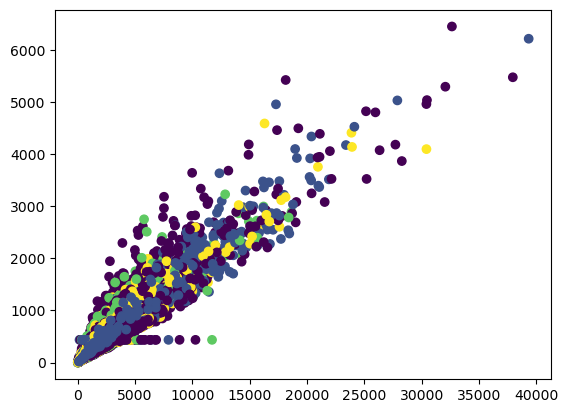

In [103]:
colors = df_all['ocean_proximity'].astype('category').cat.codes

# 2. Plot dengan 1 kolom X dan 1 kolom Y
plt.scatter(
    df_all['total_rooms'],    # Sumbu X (1 kolom)
    df_all['total_bedrooms'], # Sumbu Y (1 kolom)
    c=colors,                 # Warna berdasarkan kode angka
    cmap='viridis'            # Skema warna
)

In [104]:
from imblearn.over_sampling import SMOTE

In [106]:
oversample = SMOTE(k_neighbors=4)
X,y = oversample.fit_resample(df_all[feature],df_all['ocean_proximity'])

In [109]:
X.shape,y.shape

((45680, 5), (45680,))

In [114]:
oversample_df = pd.concat([X,y],axis=1)

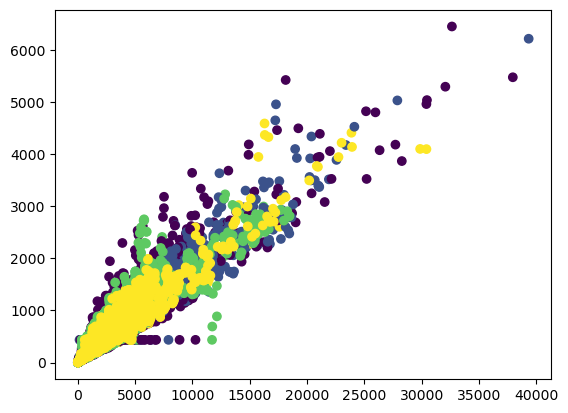

In [116]:
colors = oversample_df['ocean_proximity'].astype('category').cat.codes
plt.scatter(oversample_df['total_rooms'],
            oversample_df['total_bedrooms'],
            c=colors,        
            cmap='viridis'    )

## Handling Outlier

<Axes: >

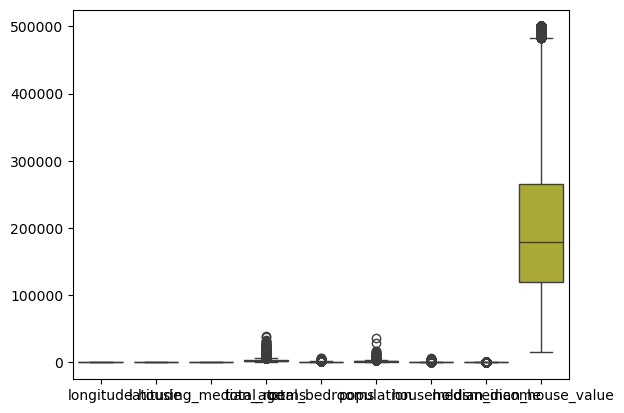

In [118]:
sns.boxplot(df)

In [121]:
# 1 colom
minimum,Q1,median,Q3,maximum = np.quantile(df['total_rooms'],[0,0.25,0.50,0.75,1.0])
minimum,Q1,median,Q3,maximum

(np.float64(2.0),
 np.float64(1447.75),
 np.float64(2127.0),
 np.float64(3148.0),
 np.float64(39320.0))

In [127]:
#semua kolom
quartiles = df.select_dtypes(include=[np.number]).quantile([0, 0.25, 0.5, 0.75, 1.0])

quartiles.index = ["minimum","Q1","median","Q3","Maximum"]

print(quartiles)

         longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
minimum    -124.35     32.54                 1.0         2.00             1.0   
Q1         -121.80     33.93                18.0      1447.75           296.0   
median     -118.49     34.26                29.0      2127.00           435.0   
Q3         -118.01     37.71                37.0      3148.00           647.0   
Maximum    -114.31     41.95                52.0     39320.00          6445.0   

         population  households  median_income  median_house_value  
minimum         3.0         1.0        0.49990             14999.0  
Q1            787.0       280.0        2.56340            119600.0  
median       1166.0       409.0        3.53480            179700.0  
Q3           1725.0       605.0        4.74325            264725.0  
Maximum     35682.0      6082.0       15.00010            500001.0  


In [129]:
# inter quartil range
IQR = quartiles.loc['Q3'] - quartiles.loc['Q1']
print(IQR)

longitude                  3.79000
latitude                   3.78000
housing_median_age        19.00000
total_rooms             1700.25000
total_bedrooms           351.00000
population               938.00000
households               325.00000
median_income              2.17985
median_house_value    145125.00000
dtype: float64


In [136]:
# batas bawah dan atas

lower_fence = quartiles.loc["Q1"]-1.5*(IQR)
higher_fence = quartiles.loc["Q1"]+1.5*(IQR)

print("\nbatas bawah: ",lower_fence)
print("\nbatas atas: ",higher_fence)


batas bawah:  longitude              -127.485000
latitude                 28.260000
housing_median_age      -10.500000
total_rooms           -1102.625000
total_bedrooms         -230.500000
population             -620.000000
households             -207.500000
median_income            -0.706375
median_house_value   -98087.500000
dtype: float64

batas atas:  longitude               -116.115000
latitude                  39.600000
housing_median_age        46.500000
total_rooms             3998.125000
total_bedrooms           822.500000
population              2194.000000
households               767.500000
median_income              5.833175
median_house_value    337287.500000
dtype: float64


In [160]:
df_num = df.select_dtypes(include=[np.number])
outliers_index = df[((df_num < lower_fence) | (df_num > higher_fence)).any(axis=1)].index
df_clean = df.drop(outliers_index)


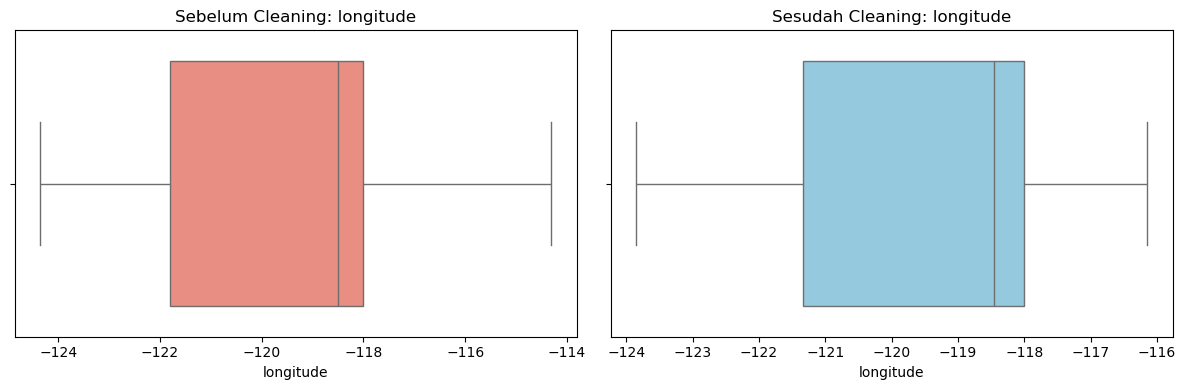

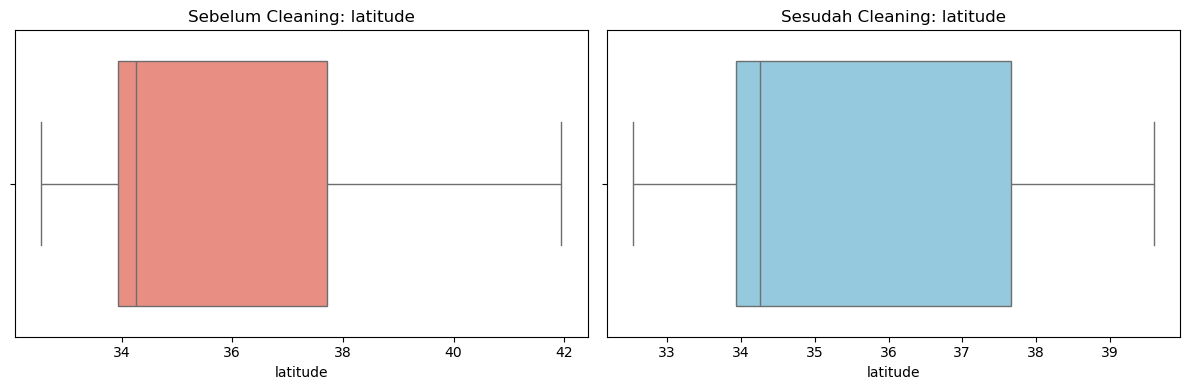

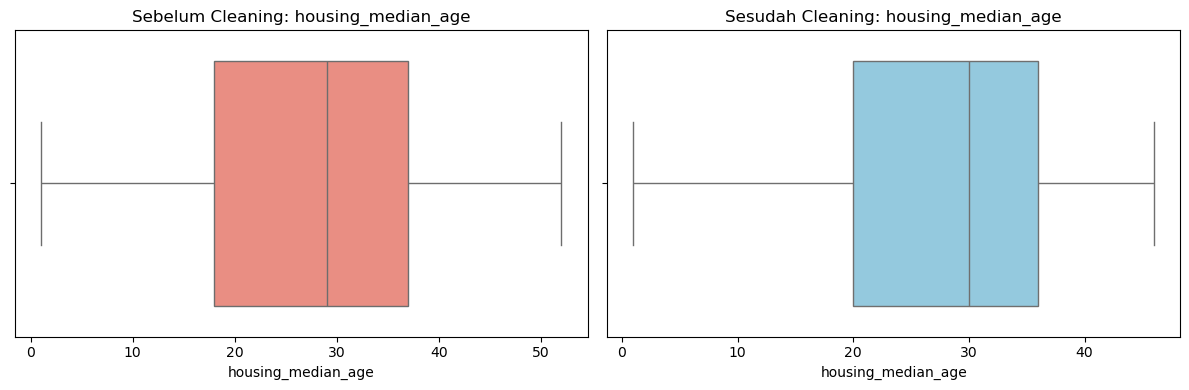

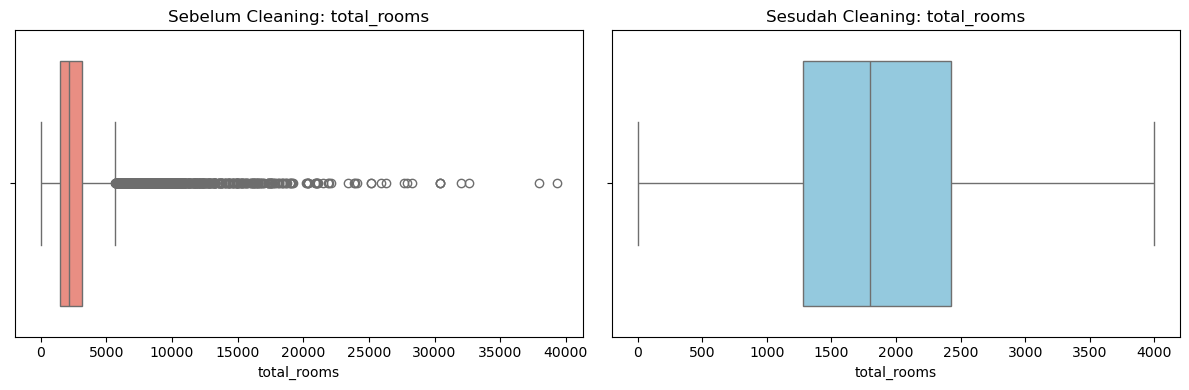

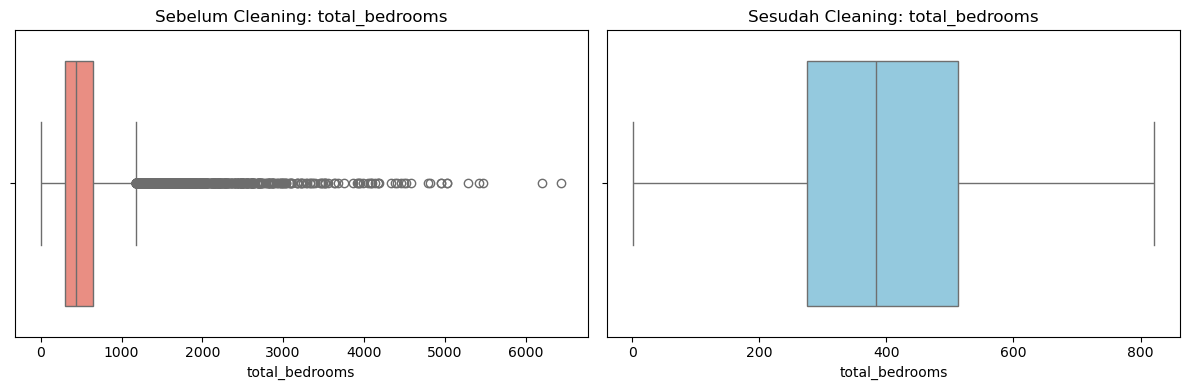

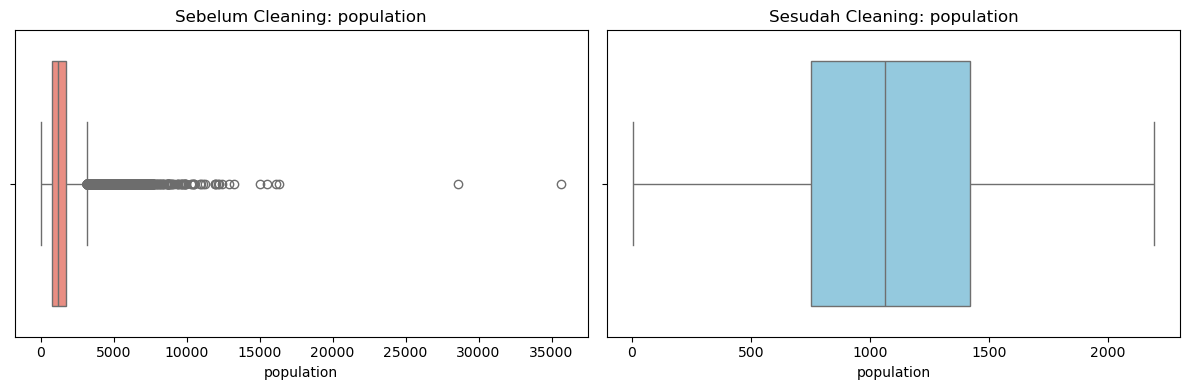

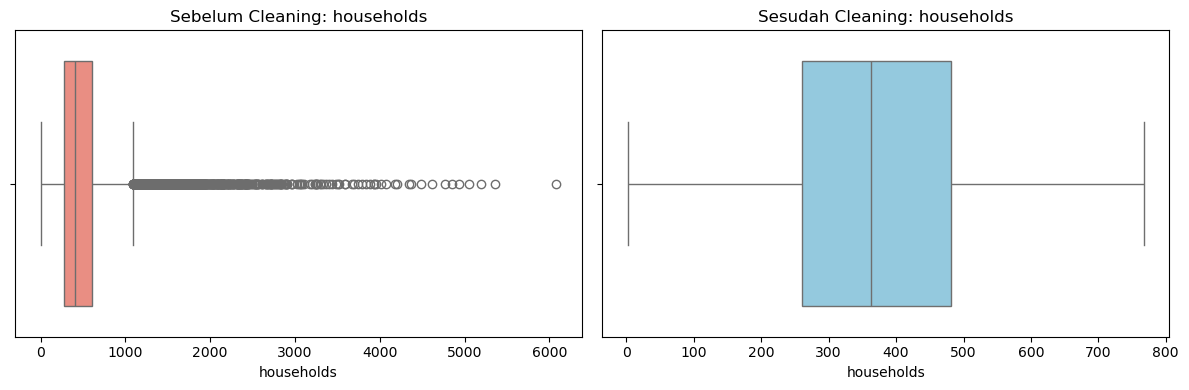

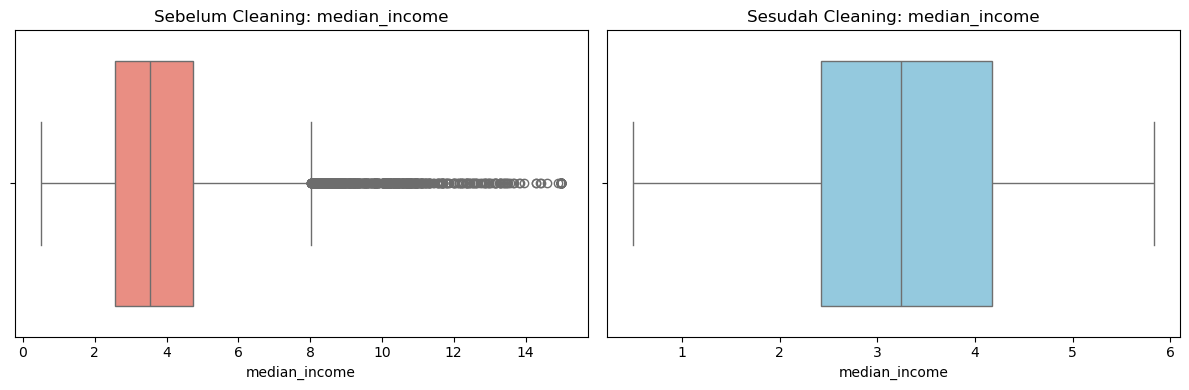

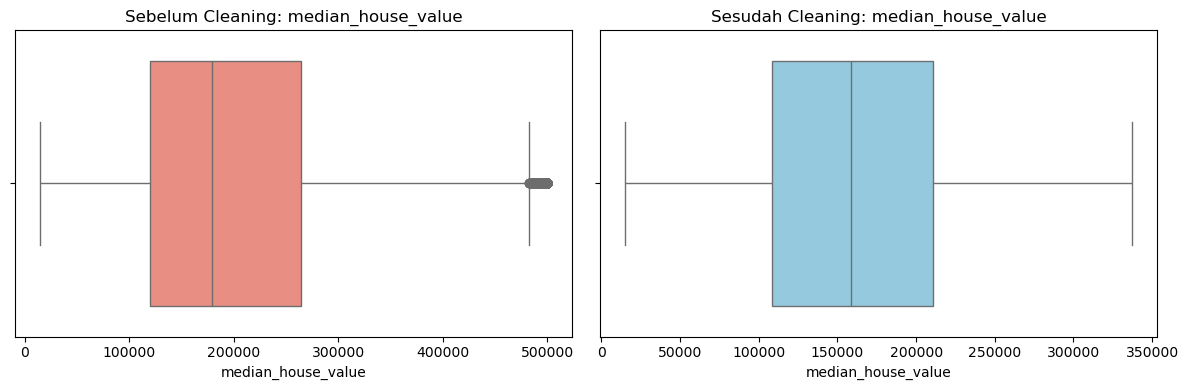

In [162]:
# Pilih kolom yang ingin dilihat, misal 'total_rooms'
fitur_numerik = df_num.columns

for col in fitur_numerik:
    plt.figure(figsize=(12, 4))
    
    # Boxplot Sebelum
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f'Sebelum Cleaning: {col}')
    
    # Boxplot Sesudah
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_clean[col], color='skyblue')
    plt.title(f'Sesudah Cleaning: {col}')
    
    plt.tight_layout()
    plt.show()